<a href="https://colab.research.google.com/github/deepakvarghesevm/Intermediate_assessment_deepak/blob/main/Intermediate_assessment_deepak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools we will need later
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report

# Hide warning messages to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Same seed everywhere so results are repeatable
RANDOM_STATE = 42

print("Libraries imported")

Libraries imported


In [2]:
train = pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/Intermediate_assessment_deepak/train_LZdllcl.csv')
test = pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/Intermediate_assessment_deepak/test_2umaH9m.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/Intermediate_assessment_deepak/sample_submission_M0L0uXE.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (54808, 14)
Test shape: (23490, 13)
Sample submission shape: (23490, 2)


In [3]:
train.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  KPIs_met >80%         23490 non-null  int64  
 11  awards_won?           23490 non-null  int64  
 12  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.3+ MB


In [6]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [8]:
print("Missing values in TRAIN:")
print(train.isnull().sum())
print()
print("Missing values in TEST:")
print(test.isnull().sum())

Missing values in TRAIN:
employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

Missing values in TEST:
employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [9]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())
print("employee_id unique in train:", train['employee_id'].is_unique)
print("employee_id unique in test:", test['employee_id'].is_unique)

Duplicate rows in train: 0
Duplicate rows in test: 0
employee_id unique in train: True
employee_id unique in test: True


In [10]:
print(train['is_promoted'].value_counts())
print()
print(train['is_promoted'].value_counts(normalize=True).round(4) * 100)

is_promoted
0    50140
1     4668
Name: count, dtype: int64

is_promoted
0    91.48
1     8.52
Name: proportion, dtype: float64




```
The data has 54,808 employees and 14 columns, and the test file has the same columns minus the target.
Only two columns have missing values: education and previous_year_rating.
There are no duplicates, and employee_id is just an identifier, so it won't be a feature.
The target is heavily imbalanced (8.5% promoted), which is why we will use F1 instead of accuracy
```



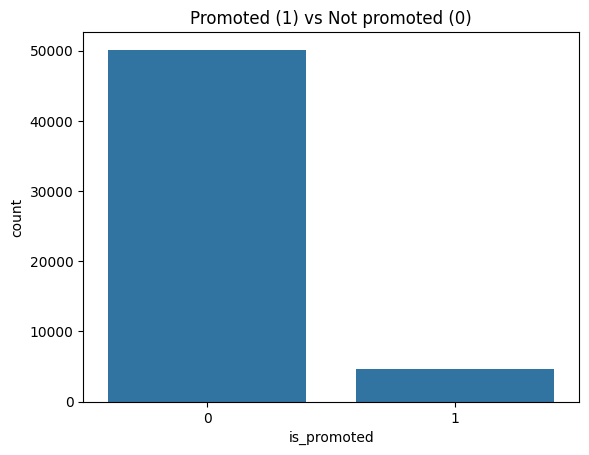

In [11]:
sns.countplot(x='is_promoted', data=train)
plt.title('Promoted (1) vs Not promoted (0)')
plt.show()

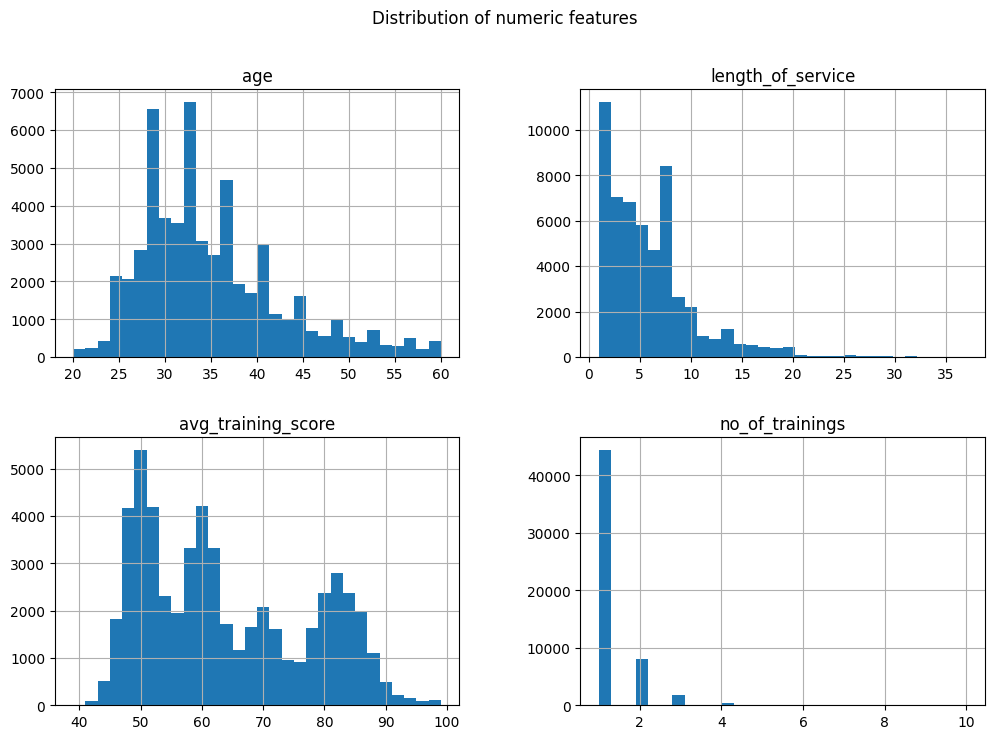

In [12]:
# Histograms of the numeric columns
num_cols = ['age', 'length_of_service', 'avg_training_score', 'no_of_trainings']

train[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of numeric features')
plt.show()

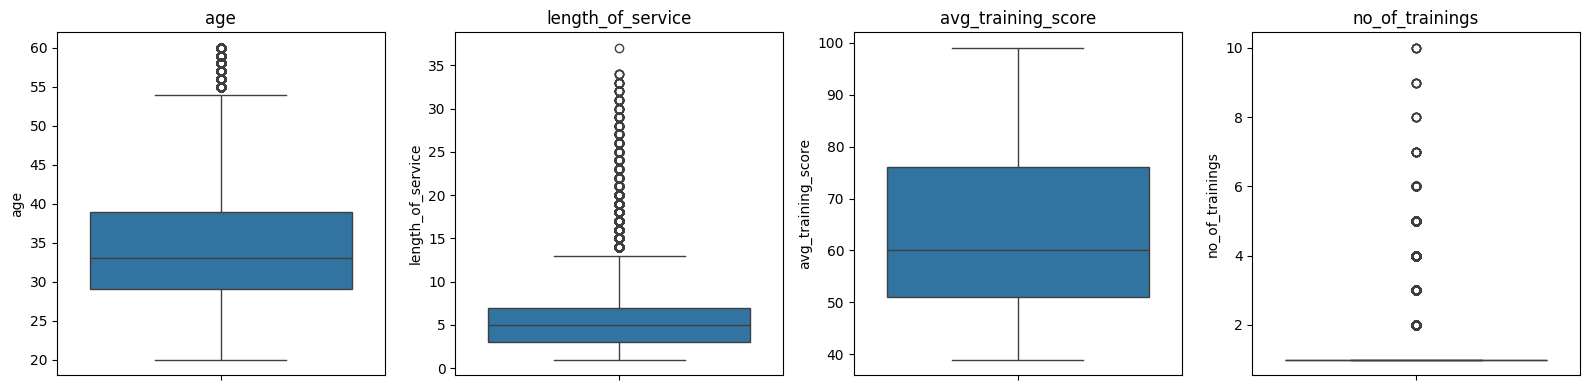

In [13]:
# Boxplots to spot outliers (we will NOT remove any rows)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=train[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

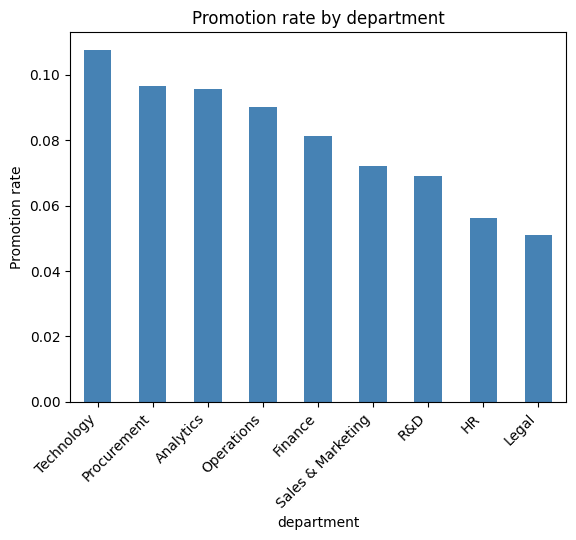

In [14]:
# Department
dept_rate = train.groupby('department')['is_promoted'].mean().sort_values(ascending=False)
dept_rate.plot(kind='bar', color='steelblue')
plt.title('Promotion rate by department')
plt.ylabel('Promotion rate')
plt.xticks(rotation=45, ha='right')
plt.show()

In [16]:
# 1) Flag for new employees (1 year of service). Create it BEFORE filling anything.
train['is_new_employee'] = (train['length_of_service'] == 1).astype(int)

# 2) previous_year_rating: missing means "no rating yet" (new employee), so fill with 0
train['previous_year_rating'] = train['previous_year_rating'].fillna(0)

# 3) education: missing becomes its own category "Unknown"
train['education'] = train['education'].fillna('Unknown')

print("Train done")

Train done


In [17]:
test['is_new_employee'] = (test['length_of_service'] == 1).astype(int)
test['previous_year_rating'] = test['previous_year_rating'].fillna(0)
test['education'] = test['education'].fillna('Unknown')

print("Test done")

Test done


In [18]:
print("Total missing in TRAIN:", train.isnull().sum().sum())
print("Total missing in TEST:", test.isnull().sum().sum())
print()
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()
print(train['education'].value_counts())
print()
print(train['previous_year_rating'].value_counts().sort_index())
print()
print(train['is_new_employee'].value_counts())

Total missing in TRAIN: 0
Total missing in TEST: 0

Train shape: (54808, 15)
Test shape: (23490, 14)

education
Bachelor's          36669
Master's & above    14925
Unknown              2409
Below Secondary       805
Name: count, dtype: int64

previous_year_rating
0.0     4124
1.0     6223
2.0     4225
3.0    18618
4.0     9877
5.0    11741
Name: count, dtype: int64

is_new_employee
0    50261
1     4547
Name: count, dtype: int64


In [19]:
num_cols = ['age', 'length_of_service', 'avg_training_score', 'no_of_trainings']

for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (train[col] < low) | (train[col] > high)
    print(f"{col:20s} range kept: {low:.1f} to {high:.1f} | "
          f"outliers: {mask.sum()} ({mask.mean()*100:.1f}%) | "
          f"min: {train[col].min()}, max: {train[col].max()}")

age                  range kept: 14.0 to 54.0 | outliers: 1435 (2.6%) | min: 20, max: 60
length_of_service    range kept: -3.0 to 13.0 | outliers: 3489 (6.4%) | min: 1, max: 37
avg_training_score   range kept: 13.5 to 113.5 | outliers: 0 (0.0%) | min: 39, max: 99
no_of_trainings      range kept: 1.0 to 1.0 | outliers: 10430 (19.0%) | min: 1, max: 10


In [20]:
train = train.rename(columns={'KPIs_met >80%': 'kpis_met', 'awards_won?': 'awards_won'})
test = test.rename(columns={'KPIs_met >80%': 'kpis_met', 'awards_won?': 'awards_won'})

print(list(train.columns))

['employee_id', 'department', 'region', 'education', 'gender', 'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'kpis_met', 'awards_won', 'avg_training_score', 'is_promoted', 'is_new_employee']


In [22]:
# Average training score of each department, calculated on train only
dept_avg_score = train.groupby('department')['avg_training_score'].mean()
print(dept_avg_score.round(2))

department
Analytics            84.60
Finance              60.22
HR                   50.02
Legal                59.87
Operations           60.23
Procurement          70.12
R&D                  84.60
Sales & Marketing    50.26
Technology           79.93
Name: avg_training_score, dtype: float64


In [23]:
# 1) How old the employee was when joining
train['age_at_joining'] = train['age'] - train['length_of_service']

# 2) KPIs met multiplied by rating (high only if BOTH are good)
train['kpi_x_rating'] = train['kpis_met'] * train['previous_year_rating']

# 3) Training score compared with the employee's own department
train['score_vs_dept'] = train['avg_training_score'] - train['department'].map(dept_avg_score)

# 4) Count of positive signals: KPIs met, award won, rating of 4 or 5
train['total_signal'] = train['kpis_met'] + train['awards_won'] + (train['previous_year_rating'] >= 4).astype(int)

print("Train done")

Train done


In [24]:
test['age_at_joining'] = test['age'] - test['length_of_service']
test['kpi_x_rating'] = test['kpis_met'] * test['previous_year_rating']
test['score_vs_dept'] = test['avg_training_score'] - test['department'].map(dept_avg_score)   # uses TRAIN averages
test['total_signal'] = test['kpis_met'] + test['awards_won'] + (test['previous_year_rating'] >= 4).astype(int)

print("Test done")

Test done


In [25]:
train['gender'] = train['gender'].map({'m': 1, 'f': 0})
test['gender'] = test['gender'].map({'m': 1, 'f': 0})

print("Missing gender in train:", train['gender'].isnull().sum())
print("Missing gender in test:", test['gender'].isnull().sum())
print(train['gender'].value_counts())

Missing gender in train: 0
Missing gender in test: 0
gender
1    38496
0    16312
Name: count, dtype: int64


In [26]:
cat_cols = ['education', 'department', 'recruitment_channel', 'region']

train_enc = pd.get_dummies(train, columns=cat_cols, dtype=int)

print("Train before:", train.shape)
print("Train after:", train_enc.shape)

Train before: (54808, 19)
Train after: (54808, 65)


In [27]:
test_enc = pd.get_dummies(test, columns=cat_cols, dtype=int)

print("Test before:", test.shape)
print("Test after:", test_enc.shape)

Test before: (23490, 18)
Test after: (23490, 64)


In [28]:
# X = features only (no ID, no target)
X = train_enc.drop(columns=['employee_id', 'is_promoted'])
y = train_enc['is_promoted']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (54808, 63)
y shape: (54808,)


In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,                 # keeps the 8.5% promoted ratio in both parts
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("Promoted in y_train:", y_train.sum(), f"({y_train.mean()*100:.2f}%)")
print("Promoted in y_val:  ", y_val.sum(), f"({y_val.mean()*100:.2f}%)")

X_train: (43846, 63) | X_val: (10962, 63)
Promoted in y_train: 3734 (8.52%)
Promoted in y_val:   934 (8.52%)


In [31]:
# Keep the IDs aside for the submission file in Step 12
test_ids = test_enc['employee_id']

# Same columns, same order as X. A missing column would be filled with 0.
X_test = test_enc.drop(columns=['employee_id']).reindex(columns=X.columns, fill_value=0)

print("X_test shape:", X_test.shape)
print("Columns identical and in the same order:", list(X_test.columns) == list(X.columns))
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

X_test shape: (23490, 63)
Columns identical and in the same order: True
Missing values in X: 0
Missing values in X_test: 0


In [32]:
drop_for_lr = ["education_Bachelor's", 'department_Analytics',
               'recruitment_channel_other', 'region_region_1']

X_train_lr = X_train.drop(columns=drop_for_lr).copy()
X_val_lr = X_val.drop(columns=drop_for_lr).copy()
X_test_lr = X_test.drop(columns=drop_for_lr).copy()

print(X_train_lr.shape, X_val_lr.shape, X_test_lr.shape)

(43846, 59) (10962, 59) (23490, 59)


In [33]:
scale_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
              'avg_training_score', 'age_at_joining', 'kpi_x_rating',
              'score_vs_dept', 'total_signal']

scaler = StandardScaler()
scaler.fit(X_train_lr[scale_cols])           # learn the mean and spread from TRAIN only

for d in (X_train_lr, X_val_lr, X_test_lr):
    d[scale_cols] = scaler.transform(d[scale_cols])

print("Mean of scaled train columns (should be about 0):")
print(X_train_lr[scale_cols].mean().round(2))
print()
print("Std of scaled train columns (should be about 1):")
print(X_train_lr[scale_cols].std().round(2))

Mean of scaled train columns (should be about 0):
no_of_trainings         0.0
age                     0.0
previous_year_rating   -0.0
length_of_service      -0.0
avg_training_score     -0.0
age_at_joining          0.0
kpi_x_rating            0.0
score_vs_dept          -0.0
total_signal           -0.0
dtype: float64

Std of scaled train columns (should be about 1):
no_of_trainings         1.0
age                     1.0
previous_year_rating    1.0
length_of_service       1.0
avg_training_score      1.0
age_at_joining          1.0
kpi_x_rating            1.0
score_vs_dept           1.0
total_signal            1.0
dtype: float64


In [34]:
# 5-fold CV that keeps the 8.5% promoted ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []      # will hold one row per model
val_probs = {}    # will hold each model's validation probabilities (used in a preview below)

# Ratio of not-promoted to promoted, used by XGBoost and LightGBM
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(pos_weight, 2))

scale_pos_weight: 10.74


In [35]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)

cv_scores = cross_val_score(lr, X_train_lr, y_train, cv=skf, scoring='f1')
lr.fit(X_train_lr, y_train)

val_f1 = f1_score(y_val, lr.predict(X_val_lr))
val_probs['Logistic Regression'] = lr.predict_proba(X_val_lr)[:, 1]
results.append(['Logistic Regression', cv_scores.mean(), cv_scores.std(), val_f1])

print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

CV F1: 0.3790 (+/- 0.0048) | Validation F1: 0.3736


In [36]:
# Fully grown tree: no depth limit
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

print("Fully grown tree:")
print("  F1 on training data  :", round(f1_score(y_train, tree_full.predict(X_train)), 4))
print("  F1 on validation data:", round(f1_score(y_val, tree_full.predict(X_val)), 4))

Fully grown tree:
  F1 on training data  : 0.9991
  F1 on validation data: 0.4248


In [37]:
# Limited tree (max_depth=6) as the model we actually compare
tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)

cv_scores = cross_val_score(tree, X_train, y_train, cv=skf, scoring='f1')
tree.fit(X_train, y_train)

val_f1 = f1_score(y_val, tree.predict(X_val))
val_probs['Decision Tree'] = tree.predict_proba(X_val)[:, 1]
results.append(['Decision Tree', cv_scores.mean(), cv_scores.std(), val_f1])

print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

CV F1: 0.3527 (+/- 0.0058) | Validation F1: 0.3502


In [38]:
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, class_weight='balanced',
                            n_jobs=-1, random_state=RANDOM_STATE)

cv_scores = cross_val_score(rf, X_train, y_train, cv=skf, scoring='f1')
rf.fit(X_train, y_train)

val_f1 = f1_score(y_val, rf.predict(X_val))
val_probs['Random Forest'] = rf.predict_proba(X_val)[:, 1]
results.append(['Random Forest', cv_scores.mean(), cv_scores.std(), val_f1])

print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

CV F1: 0.4588 (+/- 0.0059) | Validation F1: 0.4550


In [39]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

cv_scores = cross_val_score(gb, X_train, y_train, cv=skf, scoring='f1')
gb.fit(X_train, y_train)

val_f1 = f1_score(y_val, gb.predict(X_val))
val_probs['Gradient Boosting'] = gb.predict_proba(X_val)[:, 1]
results.append(['Gradient Boosting', cv_scores.mean(), cv_scores.std(), val_f1])

print(f"CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

CV F1: 0.5067 (+/- 0.0155) | Validation F1: 0.5114


In [40]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ---- XGBoost ----
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                    scale_pos_weight=pos_weight, eval_metric='logloss',
                    random_state=RANDOM_STATE, n_jobs=-1)

cv_scores = cross_val_score(xgb, X_train, y_train, cv=skf, scoring='f1')
xgb.fit(X_train, y_train)

val_f1 = f1_score(y_val, xgb.predict(X_val))
val_probs['XGBoost'] = xgb.predict_proba(X_val)[:, 1]
results.append(['XGBoost', cv_scores.mean(), cv_scores.std(), val_f1])
print(f"XGBoost  -> CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

XGBoost  -> CV F1: 0.3928 (+/- 0.0069) | Validation F1: 0.3906


In [41]:
# ---- LightGBM ----
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                      scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
                      n_jobs=-1, verbose=-1)

cv_scores = cross_val_score(lgbm, X_train, y_train, cv=skf, scoring='f1')
lgbm.fit(X_train, y_train)

val_f1 = f1_score(y_val, lgbm.predict(X_val))
val_probs['LightGBM'] = lgbm.predict_proba(X_val)[:, 1]
results.append(['LightGBM', cv_scores.mean(), cv_scores.std(), val_f1])
print(f"LightGBM -> CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Validation F1: {val_f1:.4f}")

LightGBM -> CV F1: 0.4094 (+/- 0.0075) | Validation F1: 0.4080


In [42]:
results_df = pd.DataFrame(results, columns=['Model', 'CV F1 (mean)', 'CV F1 (std)', 'Validation F1'])
results_df.sort_values('CV F1 (mean)', ascending=False).round(4)

,Model,CV F1 (mean),CV F1 (std),Validation F1
3,Gradient Boosting,0.5067,0.0155,0.5114
2,Random Forest,0.4588,0.0059,0.4550
5,LightGBM,0.4094,0.0075,0.4080
4,XGBoost,0.3928,0.0069,0.3906
0,Logistic Regression,0.3790,0.0048,0.3736
1,Decision Tree,0.3527,0.0058,0.3502


Best threshold: 0.32 | Validation F1: 0.5260


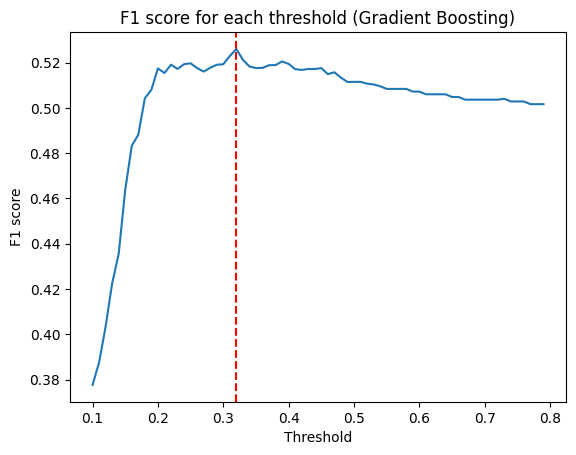

In [43]:
gb_val_probs = val_probs['Gradient Boosting']

thresholds = np.arange(0.10, 0.80, 0.01)
scores = [f1_score(y_val, (gb_val_probs >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[int(np.argmax(scores))]
print(f"Best threshold: {best_threshold:.2f} | Validation F1: {max(scores):.4f}")

plt.plot(thresholds, scores)
plt.axvline(best_threshold, color='red', linestyle='--')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 score for each threshold (Gradient Boosting)')
plt.show()

In [44]:
final_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
final_model.fit(X, y)                                   # all training rows

test_probs = final_model.predict_proba(X_test)[:, 1]
final_threshold = best_threshold
final_pred = (test_probs >= final_threshold).astype(int)

In [45]:
print("Test rows:", len(final_pred))
print("Predicted promoted:", final_pred.sum(), f"({final_pred.mean()*100:.2f}%)")
print("Missing values:", np.isnan(test_probs).sum())

Test rows: 23490
Predicted promoted: 804 (3.42%)
Missing values: 0


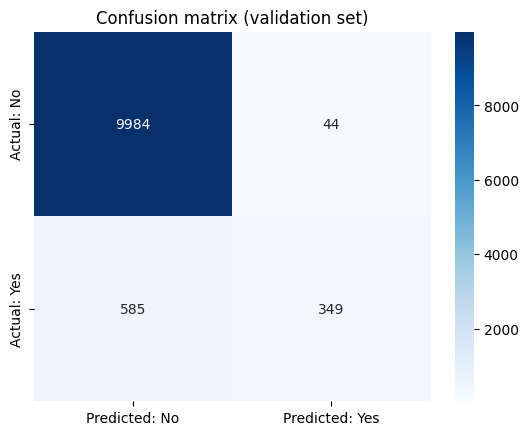

              precision    recall  f1-score   support

           0      0.945     0.996     0.969     10028
           1      0.888     0.374     0.526       934

    accuracy                          0.943     10962
   macro avg      0.916     0.685     0.748     10962
weighted avg      0.940     0.943     0.932     10962



In [52]:
val_pred = (gb_val_probs >= best_threshold).astype(int)

cm = confusion_matrix(y_val, val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion matrix (validation set)')
plt.show()

print(classification_report(y_val, val_pred, digits=3))

In [46]:
print("Sample submission before:")
print(sample_submission.head())
print()
print("Same IDs in the same order as test:",
      (sample_submission['employee_id'].values == test_ids.values).all())
print("Length of final_pred:", len(final_pred), "| rows in sample submission:", len(sample_submission))

Sample submission before:
   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0

Same IDs in the same order as test: True
Length of final_pred: 23490 | rows in sample submission: 23490


In [47]:
submission = sample_submission.copy()
submission['is_promoted'] = final_pred

submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [48]:
print("Shape:", submission.shape)
print("Columns:", list(submission.columns))
print("Data types:")
print(submission.dtypes)
print()
print("Missing values:", submission.isnull().sum().sum())
print("Unique values in is_promoted:", sorted(submission['is_promoted'].unique()))
print("Duplicate employee_ids:", submission['employee_id'].duplicated().sum())
print()
print(submission['is_promoted'].value_counts())

Shape: (23490, 2)
Columns: ['employee_id', 'is_promoted']
Data types:
employee_id    int64
is_promoted    int64
dtype: object

Missing values: 0
Unique values in is_promoted: [np.int64(0), np.int64(1)]
Duplicate employee_ids: 0

is_promoted
0    22686
1      804
Name: count, dtype: int64


In [49]:
submission.to_csv('submission_v1.csv', index=False)

from google.colab import files
files.download('submission_v1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>